# Exercise 7 - Decision Tree on Moons dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
tree = DecisionTreeClassifier(random_state=42)
param_grid = {"max_leaf_nodes": [5, 10, 15, 20, 25, 30, 40, 50], "max_depth": [None, 5, 10, 15], "min_samples_split": [2, 5, 10]}
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

best_tree = grid_search.best_estimator_
y_pred = best_tree.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))

Best parameters: {'max_depth': None, 'max_leaf_nodes': 25, 'min_samples_split': 2}
Best CV accuracy: 0.859
Test accuracy: 0.872


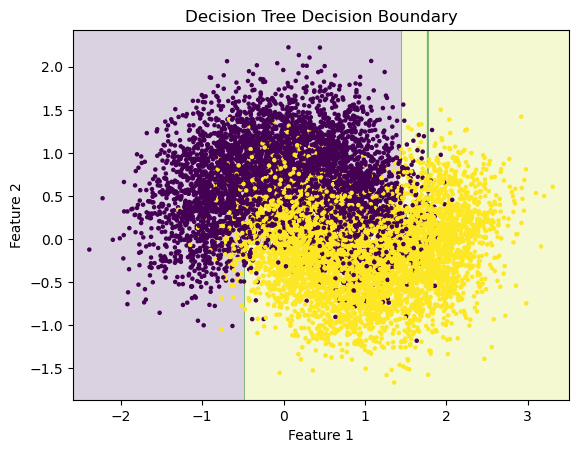

In [3]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.2, X[:, 0].max() + 0.2, 500), np.linspace(X[:, 1].min() - 0.2, X[:, 1].max() + 0.2, 500))
Z = best_tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Decision Boundary")
plt.show()